# Step 2 - Causal Communication Network

基于 Step1 输出构建空间约束因果通讯网络，并可视化关键统计。

In [ ]:
from pathlib import Path
import subprocess

ROOT = Path.cwd().resolve().parent.parent if Path.cwd().name == "example_sccrc_icb_step_by_step" else Path.cwd().resolve()
STEP1 = ROOT / "results" / "examples" / "sccrc_icb" / "step1"
STEP2 = ROOT / "results" / "examples" / "sccrc_icb" / "step2"
STEP2.mkdir(parents=True, exist_ok=True)

cmd = [
    "python", "scripts/run_step2.py",
    "--step1-dir", str(STEP1),
    "--output-dir", str(STEP2),
    "--granularity", "cluster",
    "--bootstrap-n", "20",
    "--bootstrap-threshold", "0.5",
    "--device", "cpu",
]
print(" ".join(cmd))
subprocess.run(cmd, cwd=ROOT, check=True)
print(f"Step2 done -> {STEP2}")

Step2 figure generated locally


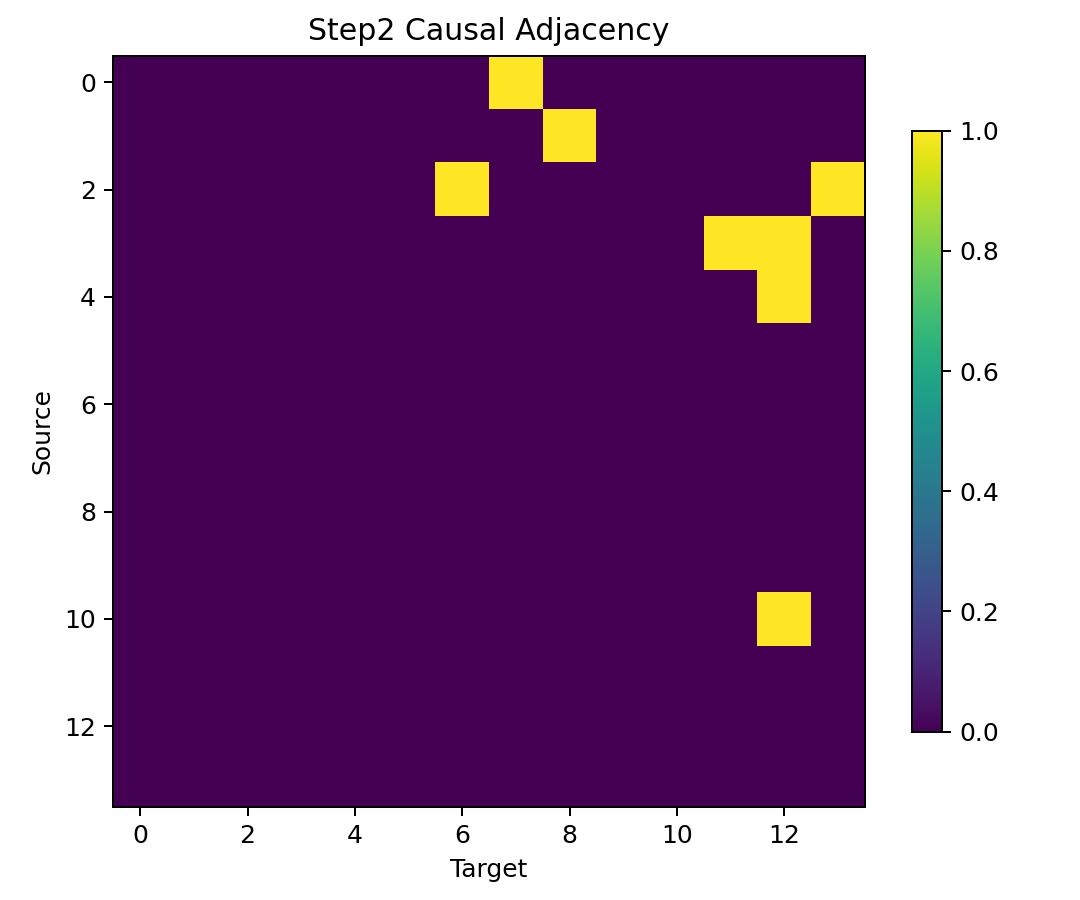

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

metrics = json.loads((STEP2 / "step2_metrics.json").read_text(encoding="utf-8"))
print(json.dumps(metrics, ensure_ascii=False, indent=2))

adj = np.load(STEP2 / "causal_adjacency.npy")
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(adj, cmap="viridis")
ax.set_title("Step2 Causal Adjacency")
ax.set_xlabel("Target node")
ax.set_ylabel("Source node")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()